In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2, f_classif
from sklearn.ensemble import RandomForestClassifier
import sklearn

# Load dataset
df = pd.read_csv("D:\\education\\SLIIT\\2nd year\\1st semester\\IT2011AI ML\\Assignment\\Employee Attrition Prediction Dataset.csv")

df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [6]:
# Encode target (Attrition: Stayed=0, Left=1)
df["Attrition_Enc"] = df["Attrition"].map({"Stayed": 0, "Left": 1})
y = df["Attrition_Enc"]

cols_to_drop = ["Employee ID"] 
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

df.head()

,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition,Attrition_Enc
0,31,Male,19,Education,5390,Excellent,Medium,Average,2,No,...,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed,0
1,59,Female,4,Media,5534,Poor,High,Low,3,No,...,Mid,Medium,21,No,No,No,Fair,Low,Stayed,0
2,24,Female,10,Healthcare,8159,Good,High,Low,0,No,...,Mid,Medium,74,No,No,No,Poor,Low,Stayed,0
3,36,Female,7,Education,3989,Good,High,High,1,No,...,Mid,Small,50,Yes,No,No,Good,Medium,Stayed,0
4,56,Male,41,Education,4821,Fair,Very High,Average,0,Yes,...,Senior,Medium,68,No,No,No,Fair,Medium,Stayed,0


In [7]:
# Drop target column
X = df.drop(columns=["Attrition", "Attrition_Enc"])

# Separate categorical & numeric features
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

sk_version = sklearn.__version__
print("Scikit-learn version:", sk_version)

if int(sk_version.split(".")[1]) >= 2: 
    encoder = OneHotEncoder(drop="first", sparse_output=False)
else:  
    encoder = OneHotEncoder(drop="first", sparse=False)

# Encode categoricals
X_encoded = pd.DataFrame(
    encoder.fit_transform(X[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols)
)

X_all = pd.concat([X[numeric_cols].reset_index(drop=True),
                   X_encoded.reset_index(drop=True)], axis=1)

print("Final feature matrix shape:", X_all.shape)
X_all.head()


Scikit-learn version: 1.6.1
Final feature matrix shape: (74498, 41)


,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure,Gender_Male,Job Role_Finance,Job Role_Healthcare,...,Company Size_Small,Remote Work_Yes,Leadership Opportunities_Yes,Innovation Opportunities_Yes,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,31,19,5390,2,22,0,89,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,59,4,5534,3,21,3,21,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,24,10,8159,0,11,3,74,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,36,7,3989,1,27,2,50,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,56,41,4821,0,71,0,68,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


Top 10 features by Mutual Information:
 Marital Status_Single     0.046385
Job Level_Senior          0.040670
Marital Status_Married    0.033574
Remote Work_Yes           0.029118
Gender_Male               0.011540
Work-Life Balance_Fair    0.011432
Number of Promotions      0.010949
Number of Dependents      0.008769
Work-Life Balance_Good    0.007903
Years at Company          0.007885
dtype: float64


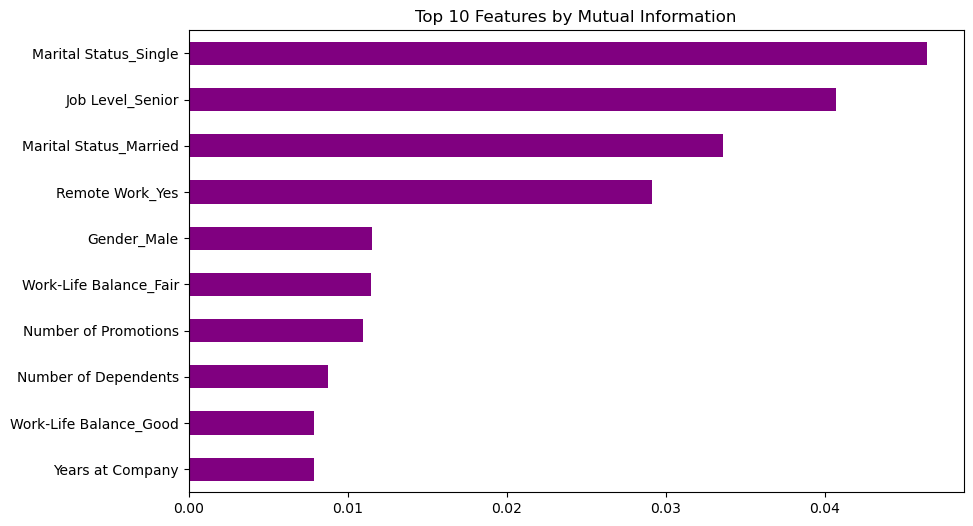

In [8]:
# Mutual Information Scores
mi_scores = mutual_info_classif(X_all, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_all.columns).sort_values(ascending=False)

# Show top 10 features
print("Top 10 features by Mutual Information:\n", mi_series.head(10))

# Visualization
plt.figure(figsize=(10,6))
mi_series.head(10).plot(kind="barh", color="purple")
plt.title("Top 10 Features by Mutual Information")
plt.gca().invert_yaxis()
plt.show()

Top 10 features (Chi-Square): ['Age', 'Years at Company', 'Monthly Income', 'Distance from Home', 'Work-Life Balance_Fair', 'Education Level_PhD', 'Marital Status_Married', 'Marital Status_Single', 'Job Level_Senior', 'Remote Work_Yes']


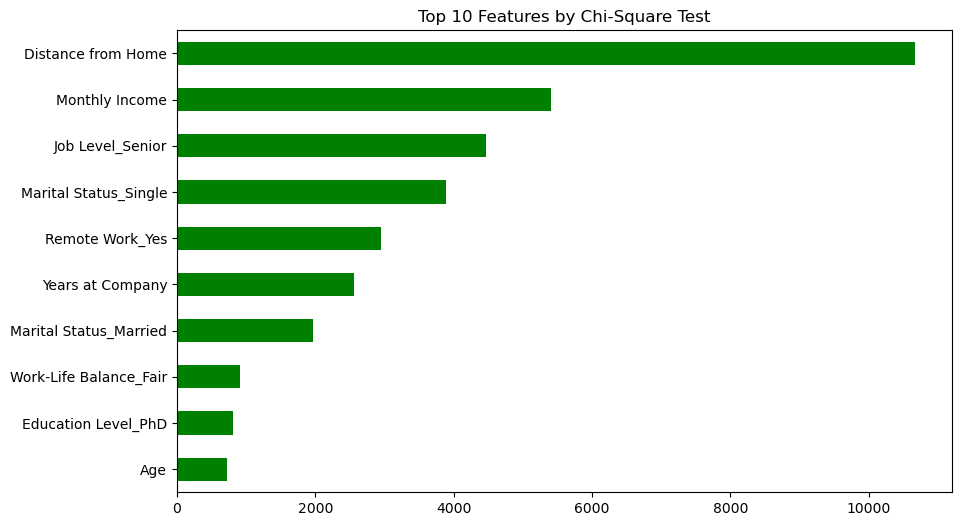

In [9]:
chi2_selector = SelectKBest(score_func=chi2, k=10)
chi2_selector.fit(abs(X_all), y) 
chi2_features = X_all.columns[chi2_selector.get_support()].tolist()

print("Top 10 features (Chi-Square):", chi2_features)

chi2_scores = pd.Series(chi2_selector.scores_, index=X_all.columns)
chi2_scores.nlargest(10).plot(kind='barh', figsize=(10,6), color="green")
plt.title("Top 10 Features by Chi-Square Test")
plt.gca().invert_yaxis()
plt.show()


Top 10 features (ANOVA F-test): ['Distance from Home', 'Gender_Male', 'Work-Life Balance_Fair', 'Work-Life Balance_Good', 'Work-Life Balance_Poor', 'Education Level_PhD', 'Marital Status_Married', 'Marital Status_Single', 'Job Level_Senior', 'Remote Work_Yes']


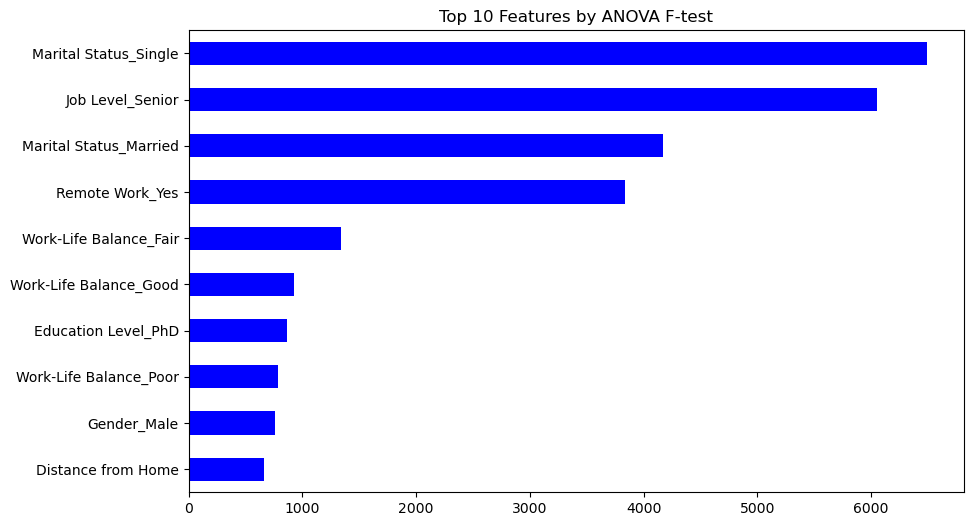

In [10]:
f_selector = SelectKBest(score_func=f_classif, k=10)
f_selector.fit(X_all, y)
f_features = X_all.columns[f_selector.get_support()].tolist()

print("Top 10 features (ANOVA F-test):", f_features)

f_scores = pd.Series(f_selector.scores_, index=X_all.columns)
f_scores.nlargest(10).plot(kind='barh', figsize=(10,6), color="blue")
plt.title("Top 10 Features by ANOVA F-test")
plt.gca().invert_yaxis()
plt.show()

Top 10 features (Random Forest):
 Distance from Home       0.081405
Monthly Income           0.078136
Company Tenure           0.073669
Job Level_Senior         0.071786
Age                      0.068234
Years at Company         0.068045
Marital Status_Single    0.055137
Remote Work_Yes          0.047255
Number of Dependents     0.042266
Number of Promotions     0.037679
dtype: float64


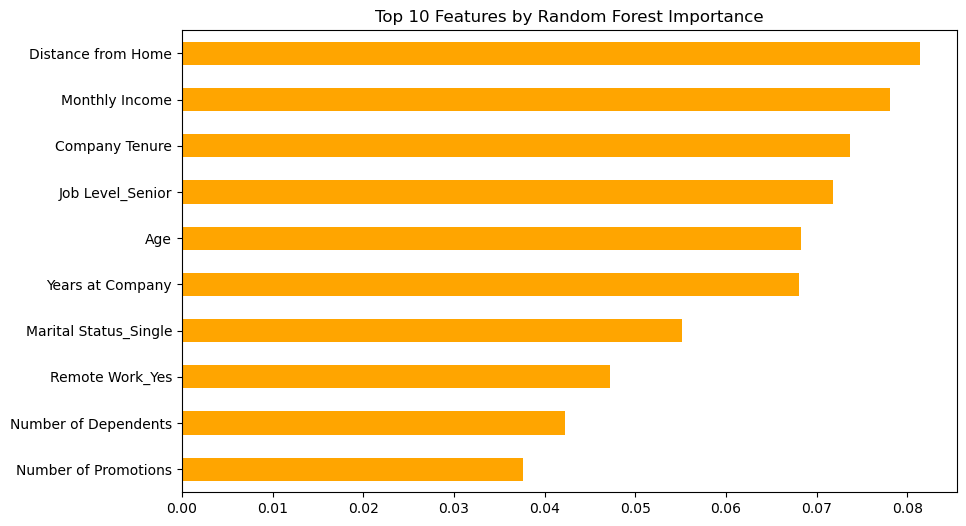

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_all, y)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=X_all.columns).sort_values(ascending=False)

print("Top 10 features (Random Forest):\n", importances.head(10))

# Visualization
plt.figure(figsize=(10,6))
importances.head(10).plot(kind="barh", color="orange")
plt.title("Top 10 Features by Random Forest Importance")
plt.gca().invert_yaxis()
plt.show()

In [12]:
output_path = "D:\\education\\SLIIT\\2nd year\\1st semester\\IT2011AI ML\\Assignment\\Employee Attrition Prediction Dataset.csv"
df.to_csv(output_path, index=False)